# Projet de fin de formation – Data Analyst

## Analyse exploratoire (EDA)

### Jeu de données : TheLook Ecommerce

Périmètre :
- France
- Produits Femme
- Années 2023 et 2024

In [1]:
#%pip install pandas numpy
#%pip install matplotlib

In [2]:
#import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#import du fichier en csv - initialisation du datframe
df = pd.read_csv("../data/thelook_fr_women_2023_2024.csv")

In [4]:
df.head()

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.500000,16.048000,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.000000,10.000000,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
2,4710,6730,11792,2023-01-03 04:44:50+00:00,Complete,38.000000,18.468000,Intimates,Women,American Apparel,American Apparel Striped Chiffon Tank,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
3,16618,24006,329,2023-01-03 15:13:39+00:00,Complete,27.990000,16.402140,Tops & Tees,Women,Tri-Mountain,Tri-Mountain Women's 3/4-Sleeve Pique Knit Pol...,Complete,2023-01-03 18:58:00+00:00,2023-01-05 13:23:00+00:00,2023-01-09 10:25:00+00:00,13422,F,France,Hauts-de-France,Comines
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.880001,29.577601,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris


In [5]:
print(f"Ce dataset est composé de : \n{df.shape[0]} lignes\n{df.shape[1]} colonnes")

Ce dataset est composé de : 
1679 lignes
20 colonnes


## Dictionnaire des colonnes

In [6]:
print(f"Informations sur le type des colonnes du dataset:")
print(df.info())

Informations sur le type des colonnes du dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   str    
 4   item_status       1679 non-null   str    
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   str    
 8   department        1679 non-null   str    
 9   brand             1677 non-null   str    
 10  product_name      1679 non-null   str    
 11  order_status      1679 non-null   str    
 12  order_created_at  1679 non-null   str    
 13  shipped_at        1133 non-null   str    
 14  delivered_at      636 non-null    str    
 15  user_id           1679 non-null   int64  
 16  gen

In [7]:
print("Colonnes contenant des valeurs non renseignées:\n")
valeurmanquante = df.isna().sum()
print(valeurmanquante[valeurmanquante>0])
print("A ce stade de l'étude, il n'est pas encore possible de déterminer l'importance ou non de ces colonnes.")
print("Nul besoin pour l'instant d'apporter une stratégie sur ces données manquantes.")

Colonnes contenant des valeurs non renseignées:

brand              2
shipped_at       546
delivered_at    1043
dtype: int64
A ce stade de l'étude, il n'est pas encore possible de déterminer l'importance ou non de ces colonnes.
Nul besoin pour l'instant d'apporter une stratégie sur ces données manquantes.


In [8]:
print(f"Statistiques du dataset :")
print(df.describe())

Statistiques du dataset :
            order_id  order_item_id    product_id   sale_price         cost  \
count    1679.000000    1679.000000   1679.000000  1679.000000  1679.000000   
mean    60851.683740   88372.698035   7922.506254    57.021769    27.460066   
std     35655.502994   51820.578196   4680.553838    69.682245    31.854450   
min       359.000000     517.000000     12.000000     1.820000     0.749840   
25%     30357.000000   44069.500000   3812.000000    19.990000     9.681000   
50%     60827.000000   88353.000000   7907.000000    38.000000    18.230800   
75%     90911.000000  132106.000000  12053.000000    68.000000    33.232345   
max    124791.000000  181230.000000  15982.000000   903.000000   437.052001   

            user_id  
count   1679.000000  
mean   48702.836212  
std    28441.847629  
min      279.000000  
25%    24349.000000  
50%    48715.000000  
75%    72541.000000  
max    99717.000000  


## Contrôle qualité

In [9]:
print("Présence de doublon\n Seules seront pris en compte les colonnes order_id et order_item_id \n") 

colonneorder = df[["order_id","order_item_id"]]
valeurendouble=[]
for valboucle in colonneorder:
    nb_unique=df[valboucle].nunique()
    nb_doublon = df[valboucle].duplicated().sum()
    valeurendouble.append({'colonne':valboucle, 'nombre':nb_unique, 'type':'unique'})
    valeurendouble.append({'colonne':valboucle, 'nombre':nb_doublon,'type':'doublon'})

dfdoublon =pd.DataFrame(valeurendouble)
print(dfdoublon)
print("\n")
print("""Ce qui indique que :
- un order_item_id est unique ;
- un order_id peut contenir un ou plusieurs order_item_id ;
- une commande peut contenir plusieurs items.
""")

print("Les autres colonnes de ce dataset présentent des doublons logiques de base de données")
print("Exemple: item_status, les valeurs de cette colonne sont prédéfinies ce qui implique nécessairement des doublons")

Présence de doublon
 Seules seront pris en compte les colonnes order_id et order_item_id 

         colonne  nombre     type
0       order_id    1117   unique
1       order_id     562  doublon
2  order_item_id    1679   unique
3  order_item_id       0  doublon


Ce qui indique que :
- un order_item_id est unique ;
- un order_id peut contenir un ou plusieurs order_item_id ;
- une commande peut contenir plusieurs items.

Les autres colonnes de ce dataset présentent des doublons logiques de base de données
Exemple: item_status, les valeurs de cette colonne sont prédéfinies ce qui implique nécessairement des doublons


In [10]:
print("Conversion/transformation des colonnes dates :")
print(f"Format des colonnes :")
print(df[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes)

df["item_created_at"] = pd.to_datetime(df["item_created_at"])
df["order_created_at"] = pd.to_datetime(df["order_created_at"])
df["shipped_at"] = pd.to_datetime(df["shipped_at"])
df["delivered_at"] = pd.to_datetime(df["delivered_at"])

print(f"Format des colonnes après transformation:")
print(df[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes)


Conversion/transformation des colonnes dates :
Format des colonnes :
item_created_at     str
order_created_at    str
shipped_at          str
delivered_at        str
dtype: object
Format des colonnes après transformation:
item_created_at     datetime64[us, UTC]
order_created_at    datetime64[us, UTC]
shipped_at          datetime64[us, UTC]
delivered_at        datetime64[us, UTC]
dtype: object


In [11]:
#Ajout au dataframe les colonnes mois numérique/mois alphabétique et année

df["numero_mois"]=df["order_created_at"].dt.month

df["mois"]=df["numero_mois"].map({
    1: "Janvier",
    2: "Février",
    3: "Mars",
    4: "Avril",
    5: "Mai",
    6: "Juin",
    7: "Juillet",
    8: "Août",
    9: "Septembre",
    10: "Octobre",
    11: "Novembre",
    12: "Décembre"
})

df["annee"]=df["order_created_at"].dt.year


In [12]:
print(f"Temporalité du dataset brut (order_created_at):\n")
print(f"Début : {df["order_created_at"].min()}")
print(f"au : {df["order_created_at"].max()}")


Temporalité du dataset brut (order_created_at):

Début : 2022-12-29 10:00:00+00:00
au : 2024-12-31 05:13:00+00:00


In [13]:
print(f"\nCe datatset contient les 3 derniers jours de l'année 2022")
print(f"Les informations concernant cette année 2022 seront supprimées du dataset")

df = df.query("annee != 2022")

print(f"Début : {df["order_created_at"].min()}")
print(f"au : {df["order_created_at"].max()}")



Ce datatset contient les 3 derniers jours de l'année 2022
Les informations concernant cette année 2022 seront supprimées du dataset
Début : 2023-01-03 08:12:00+00:00
au : 2024-12-31 05:13:00+00:00


In [14]:
print(f"Temporalité par année:")
dfan = df["annee"].unique()
for valboucle in dfan:
    dftempo = df.query("annee == @valboucle")
    print(f"Début {valboucle}: {dftempo["order_created_at"].min()}")
    print(f"Fin {valboucle}: {dftempo["order_created_at"].max()}\n")


Temporalité par année:
Début 2023: 2023-01-03 08:12:00+00:00
Fin 2023: 2023-12-31 18:49:00+00:00

Début 2024: 2024-01-02 13:08:00+00:00
Fin 2024: 2024-12-31 05:13:00+00:00



In [15]:
print(f"Cohérence entre date de création de l'ordre et date d'envoi")
incoherence = df[df["order_created_at"] > df["shipped_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print("\n")
print(f"Cohérence entre date de création de l'ordre et date de livraison")
incoherence = df[df["order_created_at"] > df["delivered_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print("\n")
print(f"Cohérence entre date de création de l'ordre et date de création de l'item")
incoherence = df[df["order_created_at"] > df["item_created_at"]]
ligneerreur = len(incoherence)
print(f"{ligneerreur} incohérence(s)")
print(f"Ce qui indique que certaines commandes ont une date de création postérieur aux lignes de commande")


Cohérence entre date de création de l'ordre et date d'envoi
0 incohérence(s)


Cohérence entre date de création de l'ordre et date de livraison
0 incohérence(s)


Cohérence entre date de création de l'ordre et date de création de l'item
904 incohérence(s)
Ce qui indique que certaines commandes ont une date de création postérieur aux lignes de commande


In [16]:
print("Cohérence entre statut de la commande et statut du produit")
print("""
Comme une commande peut contenir plusieurs produits,
    il s'agit de s'assurer que pour une commande = un seul statut,
    quel que soit le nombre de produit dans la commande
    """)
df["controle_satut"] = df["item_status"]==df["order_status"]
nbligneerreur = df.query("controle_satut == False").shape[0]
if nbligneerreur >0:
    print("Résultat:")
    print(f"Ce dataset présente {nbligneerreur} incohérences de statut")
else:
    print("Résultat:")
    print("Aucune incohérence de statut")


Cohérence entre statut de la commande et statut du produit

Comme une commande peut contenir plusieurs produits,
    il s'agit de s'assurer que pour une commande = un seul statut,
    quel que soit le nombre de produit dans la commande
    
Résultat:
Aucune incohérence de statut


## Analyse descriptive

In [17]:
prixmedian=df["sale_price"].mean().round(2)
print(f"Prix de vente médian : {prixmedian} €")
coutmedian=df["cost"].mean().round(2)
print(f"Coût médian : {coutmedian} €")

Prix de vente médian : 57.06 €
Coût médian : 27.48 €


In [18]:
print(f"Explorations descriptives : distributions (prix de vente, coût)")
print(df[["sale_price", "cost"]].describe().round(2))

Explorations descriptives : distributions (prix de vente, coût)
       sale_price     cost
count     1677.00  1677.00
mean        57.06    27.48
std         69.71    31.87
min          1.82     0.75
25%         19.99     9.67
50%         38.00    18.24
75%         68.00    33.28
max        903.00   437.05


## Calcul des KPI

In [19]:
def contribution(df, varexplodescrip):
    """
        df_tcd :
        définition d'un tcd qui aura index en variable. 
        ce dataframe prendra en compte toutes les valeurs du champ order_status (Cancelled,Processing,Complete...)
        Cette variable sera définit comme suit: catégorie,marque, ville
        Le choix de la variable ne sera pas demandé à l'utilisateur.
        Cette fonction sera appelée pour chacune des variables
        
        df_tcdcompleted :
        identique à df_tcd mais filtré sur order_status = 'Complete' (voir le dataframe df_completed)

        df_analyse :
        sera une concatenation des deux précédents dataframe
        ce qui donnera une vision nombre de ventes et ca fictif vs nombre de ventes et ca réel
        A partir de df_analyse : calcul du top 5 / flop 5 avec nombre de ventes et le ca associé
    """

    # Toutes les commandes 2024
    df_filtre = df.query("annee == 2024")
    df_tcd = df_filtre.pivot_table(
        index=varexplodescrip,
        values="sale_price",
        aggfunc=["count", "sum"]
    )

    df_tcd.columns = ["nb_ventes", "ca"]
    df_tcd["ca"] = df_tcd["ca"].round(2)

    # Commandes réelles
    df_completed = df_filtre.query("order_status == 'Complete'")

    df_tcdcompleted = df_completed.pivot_table(
        index=varexplodescrip,
        values="sale_price",
        aggfunc=["count", "sum"]
    )

    df_tcdcompleted.columns = ["nb_ventes_reel", "ca_reel"]
    df_tcdcompleted["ca_reel"] = df_tcdcompleted["ca_reel"].round(2)

    # jointure des deux dataframes
    df_analyse = df_tcd.join(df_tcdcompleted, how="left")

    # Remplacement des valeurs manquantes
    df_analyse[["nb_ventes_reel", "ca_reel"]] = (
        df_analyse[["nb_ventes_reel", "ca_reel"]].fillna(0)
    )

    df_analyse["nb_ventes_reel"] = (
        df_analyse["nb_ventes_reel"].astype(int)
    )

    # Top selon le CA réel
    df_top = df_analyse.sort_values(
        "ca_reel",
        ascending=False
    ).head(5)

    # Flop selon le CA réel 
    df_flop = df_analyse.sort_values(
        "ca_reel",
        ascending=True
    ).head(5)

    return {
        "tcd": df_analyse,
        "top": df_top,
        "flop": df_flop
    }

In [20]:
print("Volume de commande potentiel vs réel par catégorie (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df, "category")

print("Top 5")
print(resultat["top"])

print("\nFlop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par catégorie (trié par ca)
Rappel : réel = order_status : Complete

Top 5
                               nb_ventes       ca  nb_ventes_reel  ca_reel
category                                                                  
Outerwear & Coats                     33  3966.19              10  1755.31
Jeans                                 53  5644.56              13  1537.59
Intimates                            137  4609.87              45  1426.16
Fashion Hoodies & Sweatshirts         64  3148.60              25  1303.86
Sweaters                              39  2851.41              18  1236.53

Flop 5
                     nb_ventes       ca  nb_ventes_reel  ca_reel
category                                                        
Clothing Sets                1   129.00               0     0.00
Jumpsuits & Rompers          5   124.24               3    49.75
Suits                       12  1168.60               2   168.06
Leggings                    32

In [21]:
print("Volume de commande potentiel vs réel par marque (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df,"brand")

print(f"Top 5")
print(resultat["top"])
print("\n")
print(f"Flop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par marque (trié par ca)
Rappel : réel = order_status : Complete

Top 5
                nb_ventes       ca  nb_ventes_reel  ca_reel
brand                                                      
Arc'teryx               2   620.00               2   620.00
PAIGE                   3   577.00               3   577.00
Jones New York         11  1231.45               4   516.99
McGinn                  2   660.00               1   330.00
Roxy                   10   435.38               7   327.34


Flop 5
                nb_ventes     ca  nb_ventes_reel  ca_reel
brand                                                    
Royal Silk              1   50.0               0      0.0
SK Hat shop             2   29.9               0      0.0
What Katie Did          2  104.0               0      0.0
Seafolly                4  450.0               0      0.0
Second Base             1   44.0               0      0.0


In [22]:
print("Volume de commande potentiel vs réel par ville (trié par ca)")
print("Rappel : réel = order_status : Complete\n")

resultat = contribution(df,"city")

print(f"Top 5")
print(resultat["top"])
print("\n")
print(f"Flop 5")
print(resultat["flop"])

Volume de commande potentiel vs réel par ville (trié par ca)
Rappel : réel = order_status : Complete

Top 5
               nb_ventes       ca  nb_ventes_reel  ca_reel
city                                                      
Paris                 51  2980.95              15   613.74
Brignoles              2   509.90               2   509.90
Malakoff               6   568.65               4   436.53
Aubagne                6   481.14               4   431.89
Saint-Chamond          6   494.42               5   396.42


Flop 5
                   nb_ventes      ca  nb_ventes_reel  ca_reel
city                                                         
Arpajon-sur-Cère           2   63.59               0      0.0
Villeneuve-Loubet          1   21.99               0      0.0
Villemaury                 1   49.45               0      0.0
Vigneux-sur-Seine          1   21.00               0      0.0
Aussonne                   2  118.00               0      0.0


Saisonnalité mensuelle - 2024
                       nb_ventes       ca
numero_mois mois                         
1           Janvier           17   920.76
2           Février           13   771.39
3           Mars              25  1181.12
4           Avril             20  1003.15
5           Mai               18   880.73
6           Juin              29  1821.52
7           Juillet           22   723.28
8           Août              23  1541.58
9           Septembre         28  1580.40
10          Octobre           26  2388.50
11          Novembre          31  1348.21
12          Décembre          27  1555.64

 Graphique:


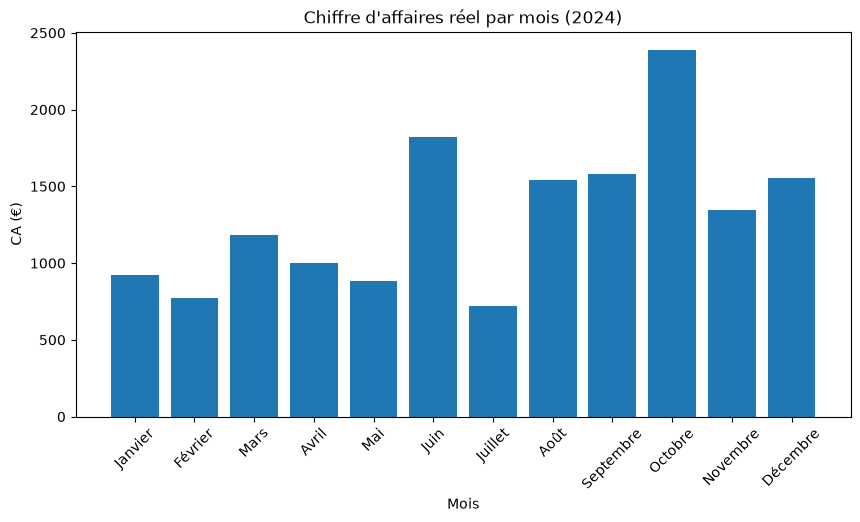

In [23]:
df_filtre = df.query("annee == 2024 and order_status == 'Complete'")

df_tcd2 = df_filtre.pivot_table(
    index=["numero_mois","mois"],
    values="sale_price",
    aggfunc=["count", "sum"]
)
df_tcd2.columns = ["nb_ventes", "ca"]

print("Saisonnalité mensuelle - 2024")
print(df_tcd2.round(2))
print("\n Graphique:")

plt.figure(figsize=(10, 5))

plt.bar(
    df_tcd2.index.get_level_values("mois"),
    df_tcd2["ca"]
)

plt.title("Chiffre d'affaires réel par mois (2024)")
plt.xlabel("Mois")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)

plt.show()

## Comparaison 2023 / 2024

In [24]:
print(f"Comparaison 2023 vs 2024 (CA réel)\n")
ordre = [
    "Janvier", "Février", "Mars", "Avril", "Mai", "Juin",
    "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"
]
df_complete = df.query("order_status == 'Complete'")
dfventes=df_complete.groupby(["annee","mois"])["sale_price"].sum().round(2).unstack(0).reindex(ordre)
dfventes.columns = ["2023", "2024"]
print(dfventes.head(12))


Comparaison 2023 vs 2024 (CA réel)

              2023     2024
mois                       
Janvier     379.06   920.76
Février     273.11   771.39
Mars        282.14  1181.12
Avril       872.30  1003.15
Mai         512.71   880.73
Juin        527.77  1821.52
Juillet     304.39   723.28
Août        863.26  1541.58
Septembre  1169.07  1580.40
Octobre    1275.83  2388.50
Novembre    439.64  1348.21
Décembre    907.04  1555.64


In [25]:
#Ajout des colonnes écarts absolus et écarts relatifs
dfventes["ecartrelatif"] = (
    ((dfventes["2024"] - dfventes["2023"]) / dfventes["2023"]) * 100).round(2)

dfventes["ecartabsolu"] = (dfventes["2024"] - dfventes["2023"]).round(2)
print(dfventes.head(12))

              2023     2024  ecartrelatif  ecartabsolu
mois                                                  
Janvier     379.06   920.76        142.91       541.70
Février     273.11   771.39        182.45       498.28
Mars        282.14  1181.12        318.63       898.98
Avril       872.30  1003.15         15.00       130.85
Mai         512.71   880.73         71.78       368.02
Juin        527.77  1821.52        245.14      1293.75
Juillet     304.39   723.28        137.62       418.89
Août        863.26  1541.58         78.58       678.32
Septembre  1169.07  1580.40         35.18       411.33
Octobre    1275.83  2388.50         87.21      1112.67
Novembre    439.64  1348.21        206.66       908.57
Décembre    907.04  1555.64         71.51       648.60


In [26]:
print(f"Les ruptures 2023-2024")
print("Pic")
print("2023 :", dfventes["2023"].idxmax(), "-", dfventes["2023"].max())
print("2024 :", dfventes["2024"].idxmax(), "-", dfventes["2024"].max())
print("\nCreux")
print("2023 :", dfventes["2023"].idxmin(), "-", dfventes["2023"].min())
print("2024 :", dfventes["2024"].idxmin(), "-", dfventes["2024"].min())

print("\nPlus forte hausse :")
print(dfventes["ecartrelatif"].idxmax(), " ", dfventes["ecartrelatif"].max(), "%")

print("\nPlus forte baisse :")
print(dfventes["ecartrelatif"].idxmin(), " ", dfventes["ecartrelatif"].min(), "%")


Les ruptures 2023-2024
Pic
2023 : Octobre - 1275.83
2024 : Octobre - 2388.5

Creux
2023 : Février - 273.11
2024 : Juillet - 723.28

Plus forte hausse :
Mars   318.63 %

Plus forte baisse :
Avril   15.0 %


Visualisation



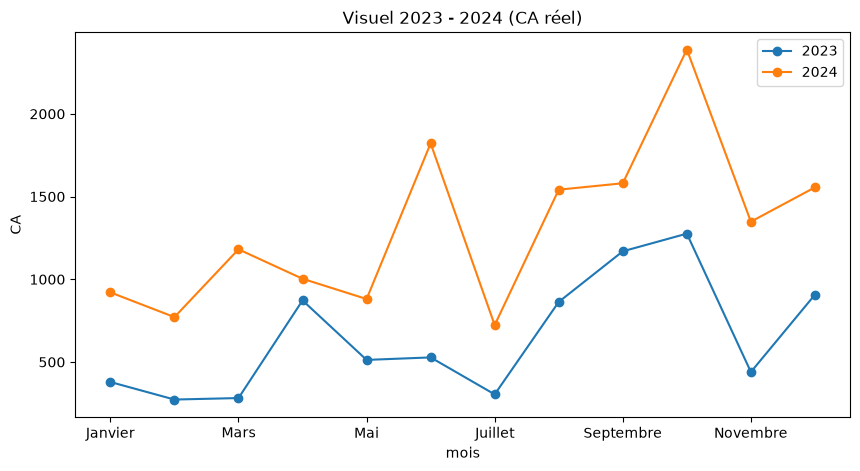

In [27]:
print(f"Visualisation\n")
dfventes[["2023","2024"]].plot(marker = "o",figsize=(10,5))
plt.title("Visuel 2023 - 2024 (CA réel)")
plt.xlabel("mois")
plt.ylabel("CA")
plt.show()


In [28]:
dfta = df.groupby("user_id")["order_id"].nunique().reset_index(name="nb_order_id")
#print(df.groupby("user_id")["order_id"].nunique())
#print(dfta.head())
print(dfta.query("nb_order_id >=2")) 

     user_id  nb_order_id
2        883            2
12      2083            2
20      2536            3
25      2835            3
30      3055            3
..       ...          ...
849    98035            3
854    98798            2
857    98817            2
861    99288            2
867    99717            2

[196 rows x 2 columns]


## Synthèse 2023 / 2024

In [32]:
def kpi(df, lannee):
    """
    création d'un dataframe filtré sur les status considérés comme vente et l'année en critères sélectionnable
    Chiffre d’affaires (somme de sale_price pour les lignes de vente).
    Marge brute (somme de sale_price – cost pour les lignes de vente).
    Panier moyen (CA / nombre de commandes avec revenu > 0).
    Taux de retour (part des lignes au statut Returned parmi les lignes vendues : ventes + retours).
    Taux de ré‑achat (part des clients ayant ≥ 2 commandes complètes sur une année).
    """
    dfkpi = df.query("order_status == 'Complete' & annee==@lannee")
    dftauxretour = df.query("(order_status == 'Complete' or order_status == 'Returned') & annee == @lannee")
    dftauxannulation = df.query("(order_status == 'Complete' or order_status == 'Cancelled') & annee == @lannee")
    nbcommande = dfkpi.groupby("user_id")["order_id"].nunique()

    return {
        "df": dfkpi,
        "ca": dfkpi["sale_price"].sum(),
        "nombre_commande":dfkpi.groupby("user_id")["order_id"].nunique().count(),
        "marge": (dfkpi["sale_price"] - dfkpi["cost"]).sum(),
        "panier": dfkpi["sale_price"].sum() / dfkpi["order_id"].nunique(),
        "taux_retour": ((dftauxretour["order_status"] == "Returned").mean() * 100),
        "taux_annulation": ((dftauxannulation["order_status"] == "Cancelled").mean() * 100),
        "taux_reachat": ((nbcommande>=2).sum() / nbcommande.count())*100
    }
while True:
    while True:
        lannee = int(input("Choisir une année (2023 ou 2024) : "))
        if lannee in [2023,2024]:
            break
        print("Année invalide. Veuillez saisir 2023 ou 2024.")

    resultat = kpi(df, lannee)
    print(f"Synthèse de l'année : {lannee}")
    print(f"{'INDICATEUR':<25}{'VALEUR':>25}")
    print("=" * 55)
    print(f"{'Chiffre d affaires':<25}{resultat['ca']:>25,.2f} €")
    print(f"{'Nombre de commande':<25}{resultat['nombre_commande']:>25}")
    print(f"{'Marge brute':<25}{resultat['marge']:>25,.2f} €")
    print(f"{'Panier moyen':<25}{resultat['panier']:>25,.2f} €")
    print(f"{'Taux de retour':<25}{resultat['taux_retour']:>24.2f} %")
    print(f"{'Taux d''annulation':<25}{resultat['taux_annulation']:>24.2f} %")
    print(f"{'Taux de réachat':<25}{resultat['taux_reachat']:>24.2f} %")
    print("=" * 55)
    print("*Taux de réachat est calculé uniquement sur les ventes : Complete")
    print("\n")

    #propose à l'utilisateur de choisir une autre année
    reponse = input("\nVoulez-vous faire un autre calcul ? (O/N) : ").strip().upper()
    if reponse != 'O':
        print(f"Calcul terminé")
        break


Synthèse de l'année : 2023
INDICATEUR                                  VALEUR
Chiffre d affaires                        7,806.32 €
Nombre de commande                              97
Marge brute                               4,075.34 €
Panier moyen                                 80.48 €
Taux de retour                              37.87 %
Taux dannulation                            39.92 %
Taux de réachat                              0.00 %
*Taux de réachat est calculé uniquement sur les ventes : Complete


Synthèse de l'année : 2024
INDICATEUR                                  VALEUR
Chiffre d affaires                       15,716.28 €
Nombre de commande                             177
Marge brute                               8,134.61 €
Panier moyen                                 85.41 €
Taux de retour                              30.42 %
Taux dannulation                            33.89 %
Taux de réachat                              3.39 %
*Taux de réachat est calculé uniquement sur 

## Conclusion
L'analyse exploratoire met en évidence une forte progression de l'activité entre 2023 et 2024. Le chiffre d'affaires passe de 7 806,32 € à 15 716,28 €, soit un doublement des ventes, tandis que la marge brute progresse de 4 075,34 € à 8 134,61 €. Cette évolution s'accompagne d'une légère augmentation du panier moyen, qui passe de 80,48 € à 85,41 €, traduisant une hausse de la valeur moyenne des commandes.

La qualité des ventes s'améliore également. Le taux de retour diminue de 37,87 % en 2023 à 30,42 % en 2024, soit une baisse de 7,45 points, ce qui laisse supposer une meilleure adéquation entre les produits proposés et les attentes des clients. En revanche, le taux de réachat reste faible (3,39 % en 2024), ce qui met en évidence un potentiel d'amélioration en matière de fidélisation.

L'analyse des ventes montre également une forte concentration du chiffre d'affaires. La catégorie Outerwear & Coats génère le chiffre d'affaires potentiel le plus élevé (10 073,57 €), devant Dresses (9 355,12 €) et Jeans (8 618,09 €). Côté marques, The North Face se distingue avec 2 711,99 € de chiffre d'affaires potentiel, tandis que Paris est la ville la plus contributrice avec 4 762,09 €, devant Marseille (2 296,68 €) et Lyon (1 080,81 €).

Enfin, la comparaison mensuelle entre 2023 et 2024 met en évidence une saisonnalité marquée. Octobre constitue le meilleur mois sur les deux exercices (5 216,54 € en 2023 et 6 607,17 € en 2024). La plus forte progression est observée en juillet (+102,55 %), alors qu'avril est le seul mois enregistrant un recul (−15,42 %). Ces résultats confirment une dynamique de croissance en 2024 tout en mettant en évidence des périodes clés sur lesquelles l'entreprise peut s'appuyer pour optimiser ses actions commerciales.